In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import joblib, os, warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully")

All libraries imported successfully


In [2]:
df = pd.read_csv('../data/Synthetic Financial Datasets For Fraud Detection.csv')

print(f"Raw dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nTransaction types available:")
print(df['type'].value_counts())
print(f"\nFraud distribution:")
print(df['isFraud'].value_counts())

Raw dataset shape: (6362620, 11)
Columns: ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']

Transaction types available:
type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

Fraud distribution:
isFraud
0    6354407
1       8213
Name: count, dtype: int64


In [3]:
df = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])].reset_index(drop=True)
df = df.sort_values(['nameOrig', 'step']).reset_index(drop=True)

print(f"After filtering — rows: {df.shape[0]}")
print(f"Fraud count  : {df['isFraud'].sum()}")
print(f"Normal count : {(df['isFraud']==0).sum()}")
print(f"\nSample rows:")
df.head()

After filtering — rows: 2770409
Fraud count  : 8213
Normal count : 2762196

Sample rows:


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,249,CASH_OUT,244486.46,C1000000639,8946.00,0.00,C785826240,526950.37,771436.84,0,0
1,327,CASH_OUT,211189.64,C1000004053,0.00,0.00,C1128041097,2609840.34,2821029.98,0,0
2,41,CASH_OUT,93865.13,C1000004530,351422.72,257557.59,C1643839147,178083.14,271948.26,0,0
3,226,TRANSFER,3228390.11,C1000005353,24996.00,0.00,C292963054,878327.64,4106717.75,0,0
4,185,CASH_OUT,233109.79,C1000005555,20623.00,0.00,C1091802600,0.00,233109.79,0,0


Normal transactions : 2762196 (99.7%)
Fraud  transactions : 8213  (0.3%)
Imbalance ratio     : 1 fraud for every 336 normal


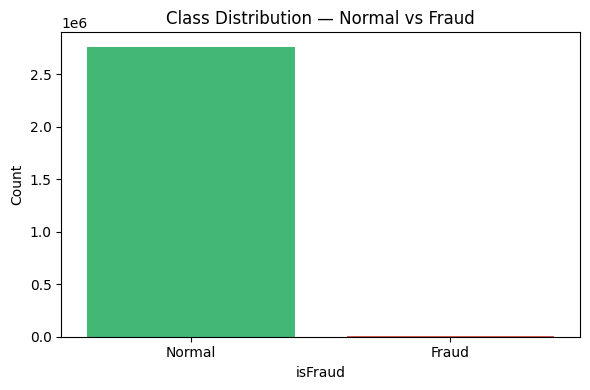

In [4]:
normal = (df['isFraud'] == 0).sum()
fraud  = (df['isFraud'] == 1).sum()
total  = len(df)

print(f"Normal transactions : {normal} ({round(normal/total*100, 2)}%)")
print(f"Fraud  transactions : {fraud}  ({round(fraud/total*100, 2)}%)")
print(f"Imbalance ratio     : 1 fraud for every {round(normal/fraud)} normal")

plt.figure(figsize=(6,4))
sns.countplot(x='isFraud', data=df, palette=['#2ecc71','#e74c3c'])
plt.title('Class Distribution — Normal vs Fraud')
plt.xticks([0,1], ['Normal', 'Fraud'])
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../data/class_distribution.png')
plt.show()

In [5]:
print("Engineering features — this will take a few minutes...")

rows = []

for sender, group in df.groupby('nameOrig'):
    group = group.reset_index(drop=True)

    for i, row in group.iterrows():
        history = group.iloc[:i]   # only past transactions of this sender

        amount  = row['amount']
        balance = row['oldbalanceOrg']

        # ── Amount ratios ─────────────────────────────────────────
        past_amounts = history['amount'].tolist()

        # Use global average as baseline for first transaction
        # so large first-time amounts are NOT treated as normal
        GLOBAL_AVG = 5000.0
        GLOBAL_MAX = 20000.0

        avg_amount = np.mean(past_amounts) if len(past_amounts) > 0 else GLOBAL_AVG
        max_amount = np.max(past_amounts)  if len(past_amounts) > 0 else GLOBAL_MAX

        amount_to_avg     = amount / avg_amount if avg_amount > 0 else 1.0
        amount_to_max     = amount / max_amount if max_amount > 0 else 1.0
        amount_to_balance = amount / balance    if balance    > 0 else 1.0

        # ── Velocity — step = 1 hour in PaySim ───────────────────
        vel_2min = len(history[history['step'] == row['step']])
        vel_1hr  = len(history[history['step'] == row['step']])

        # ── Days since last transaction ───────────────────────────
        if len(history) > 0:
            days_since = (row['step'] - history.iloc[-1]['step']) / 24
            days_since = min(days_since, 30)
        else:
            days_since = 30

        # ── Known beneficiary ─────────────────────────────────────
        past_dests = history['nameDest'].tolist()
        is_known   = 1 if row['nameDest'] in past_dests else 0

        # ── Transaction hour ──────────────────────────────────────
        txn_hour = int(row['step']) % 24

        # ── Balance drain — strongest fraud signal in PaySim ─────
        # Fraud pattern: account had money, now it is completely empty
        new_balance_orig = row['newbalanceOrig']
        balance_drain    = 1 if (balance > 0 and new_balance_orig == 0) else 0

        # ── Amount exceeds balance — another strong signal ────────
        exceeds_balance = 1 if amount >= balance else 0

        rows.append({
            'amount':                  amount,
            'amount_to_avg_ratio':     amount_to_avg,
            'amount_to_max_ratio':     amount_to_max,
            'amount_to_balance_ratio': amount_to_balance,
            'velocity_2min':           vel_2min,
            'velocity_1hr':            vel_1hr,
            'is_known_beneficiary':    is_known,
            'is_new_location':         0,
            'transaction_hour':        txn_hour,
            'days_since_last_txn':     days_since,
            'balance_drain':           balance_drain,    # new
            'exceeds_balance':         exceeds_balance,  # new
            'isFraud':                 row['isFraud']
        })

data = pd.DataFrame(rows)
print(f"Done — {len(data)} rows with 12 features engineered")
print(f"\nFraud distribution:")
print(data['isFraud'].value_counts())
print(f"\nSample rows:")
print(data.head())

# Quick check — do fraud rows have higher ratios?
print(f"\nAverage amount_to_avg_ratio:")
print(f"  Normal : {data[data['isFraud']==0]['amount_to_avg_ratio'].mean():.2f}")
print(f"  Fraud  : {data[data['isFraud']==1]['amount_to_avg_ratio'].mean():.2f}")
print(f"\nBalance drain in fraud vs normal:")
print(f"  Normal : {data[data['isFraud']==0]['balance_drain'].mean()*100:.2f}%")
print(f"  Fraud  : {data[data['isFraud']==1]['balance_drain'].mean()*100:.2f}%")

Engineering features — this will take a few minutes...
Done — 2770409 rows with 12 features engineered

Fraud distribution:
isFraud
0    2762196
1       8213
Name: count, dtype: int64

Sample rows:
       amount  amount_to_avg_ratio  amount_to_max_ratio  \
0   244486.46            48.897292            12.224323   
1   211189.64            42.237928            10.559482   
2    93865.13            18.773026             4.693257   
3  3228390.11           645.678022           161.419505   
4   233109.79            46.621958            11.655489   

   amount_to_balance_ratio  velocity_2min  velocity_1hr  is_known_beneficiary  \
0                27.329137              0             0                     0   
1                 1.000000              0             0                     0   
2                 0.267100              0             0                     0   
3               129.156269              0             0                     0   
4                11.303389              0 

In [6]:
X = data.drop(columns=['isFraud'])
y = data['isFraud']

print(f"Input features shape : {X.shape}")
print(f"Target label shape   : {y.shape}")
print(f"\nFeature columns:")
print(list(X.columns))
print(f"\nFraud label distribution:")
print(y.value_counts())

Input features shape : (2770409, 12)
Target label shape   : (2770409,)

Feature columns:
['amount', 'amount_to_avg_ratio', 'amount_to_max_ratio', 'amount_to_balance_ratio', 'velocity_2min', 'velocity_1hr', 'is_known_beneficiary', 'is_new_location', 'transaction_hour', 'days_since_last_txn', 'balance_drain', 'exceeds_balance']

Fraud label distribution:
isFraud
0    2762196
1       8213
Name: count, dtype: int64


In [7]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Features scaled successfully")
print(f"\nBefore scaling — amount stats:")
print(f"  Mean : {round(X['amount'].mean(), 2)}")
print(f"  Max  : {round(X['amount'].max(), 2)}")

print(f"\nAfter scaling — amount stats:")
print(f"  Mean : {round(X_scaled['amount'].mean(), 4)}")
print(f"  Std  : {round(X_scaled['amount'].std(), 4)}")

os.makedirs('../models', exist_ok=True)
joblib.dump(scaler, '../models/scaler.pkl')
print("\nscaler.pkl saved inside models/ folder")

Features scaled successfully

Before scaling — amount stats:
  Mean : 317536.14
  Max  : 92445516.64

After scaling — amount stats:
  Mean : 0.0
  Std  : 1.0

scaler.pkl saved inside models/ folder


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set : {X_train.shape[0]} rows")
print(f"Testing set  : {X_test.shape[0]} rows")
print(f"\nFraud in training : {y_train.sum()}")
print(f"Fraud in testing  : {y_test.sum()}")

Training set : 2216327 rows
Testing set  : 554082 rows

Fraud in training : 6570
Fraud in testing  : 1643


Applying SMOTE — please wait...


SMOTE applied successfully

Before SMOTE:
  Normal : 2209757
  Fraud  : 6570

After SMOTE:
  Normal : 2209757
  Fraud  : 2209757


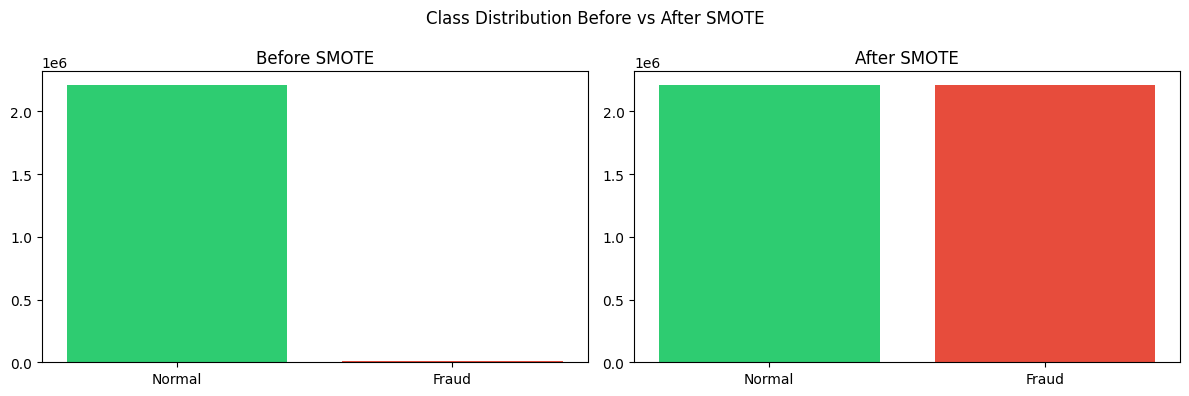

In [9]:
print("Applying SMOTE — please wait...")

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("SMOTE applied successfully")
print(f"\nBefore SMOTE:")
print(f"  Normal : {(y_train == 0).sum()}")
print(f"  Fraud  : {(y_train == 1).sum()}")
print(f"\nAfter SMOTE:")
print(f"  Normal : {(y_train_smote == 0).sum()}")
print(f"  Fraud  : {(y_train_smote == 1).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].bar(['Normal','Fraud'], [(y_train==0).sum(), (y_train==1).sum()], color=['#2ecc71','#e74c3c'])
axes[0].set_title('Before SMOTE')
axes[1].bar(['Normal','Fraud'], [(y_train_smote==0).sum(), (y_train_smote==1).sum()], color=['#2ecc71','#e74c3c'])
axes[1].set_title('After SMOTE')
plt.suptitle('Class Distribution Before vs After SMOTE')
plt.tight_layout()
plt.savefig('../data/smote_comparison.png')
plt.show()

In [10]:
print("Training XGBoost model — please wait 2-3 minutes...")

model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=1,
    eval_metric='logloss',
    random_state=42
)

model.fit(X_train_smote, y_train_smote)

print("Model trained successfully!")

y_pred       = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print(f"\nQuick accuracy check:")
print(f"  Correct predictions : {(y_pred == y_test).sum()}")
print(f"  Wrong  predictions  : {(y_pred != y_test).sum()}")
print(f"  ROC AUC Score       : {round(roc_auc_score(y_test, y_pred_proba), 4)}")
print("  (1.0 = perfect, 0.5 = random guessing)")

Training XGBoost model — please wait 2-3 minutes...
Model trained successfully!

Quick accuracy check:
  Correct predictions : 550589
  Wrong  predictions  : 3493
  ROC AUC Score       : 0.998
  (1.0 = perfect, 0.5 = random guessing)


Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00    552439
       Fraud       0.32      0.99      0.48      1643

    accuracy                           0.99    554082
   macro avg       0.66      0.99      0.74    554082
weighted avg       1.00      0.99      1.00    554082

Confusion Matrix Breakdown:
  True  Normal  (correct catches)  : 548956
  True  Fraud   (correct catches)  : 1633
  False Positive (wrong alerts)    : 3483
  False Negative (missed fraud)    : 10

Precision : 31.92%  — of all fraud alerts, how many were real fraud
Recall    : 99.39%  — of all real frauds, how many did we catch


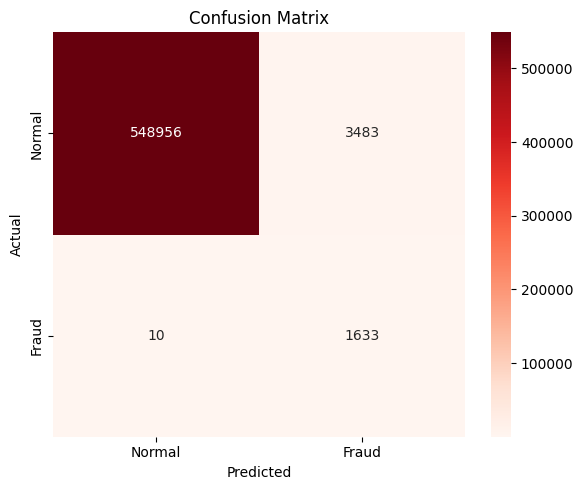

In [11]:
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraud']))

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f"Confusion Matrix Breakdown:")
print(f"  True  Normal  (correct catches)  : {tn}")
print(f"  True  Fraud   (correct catches)  : {tp}")
print(f"  False Positive (wrong alerts)    : {fp}")
print(f"  False Negative (missed fraud)    : {fn}")

precision = round(tp/(tp+fp)*100, 2)
recall    = round(tp/(tp+fn)*100, 2)
print(f"\nPrecision : {precision}%  — of all fraud alerts, how many were real fraud")
print(f"Recall    : {recall}%  — of all real frauds, how many did we catch")

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Normal','Fraud'],
            yticklabels=['Normal','Fraud'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../data/confusion_matrix.png')
plt.show()

Feature Importances:
                Feature  Importance
amount_to_balance_ratio    0.499606
          balance_drain    0.477614
                 amount    0.013824
        exceeds_balance    0.004617
       transaction_hour    0.002069
    amount_to_avg_ratio    0.001302
    amount_to_max_ratio    0.000894
    days_since_last_txn    0.000074
        is_new_location    0.000000
   is_known_beneficiary    0.000000
           velocity_1hr    0.000000
          velocity_2min    0.000000


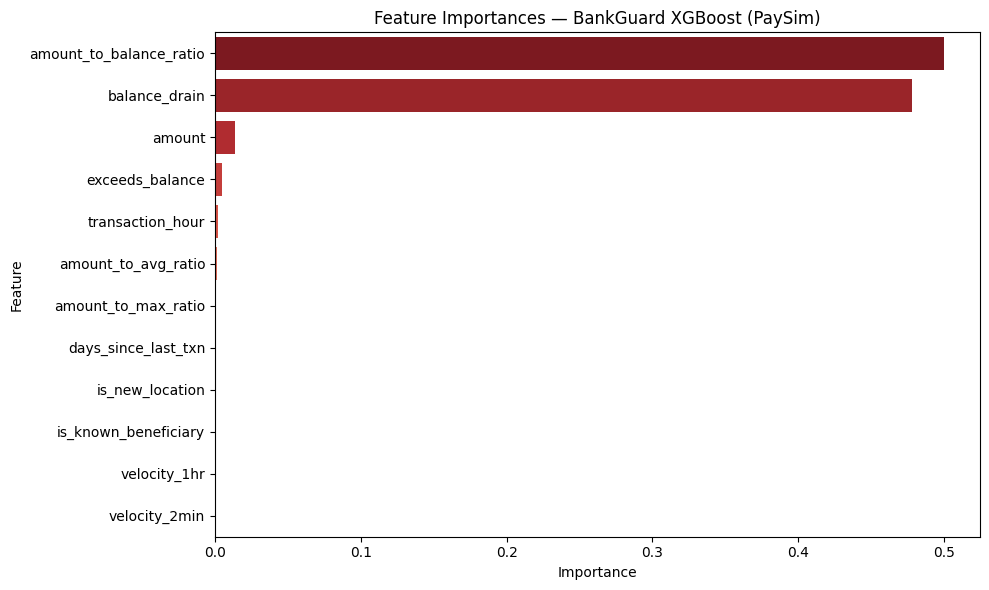


Top 3 features your model relies on most:
  amount_to_balance_ratio — 0.4996
  balance_drain — 0.4776
  amount — 0.0138


In [12]:
feature_names_list = X_train_smote.columns.tolist()
importance_df = pd.DataFrame({
    'Feature'   : feature_names_list,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Feature Importances:")
print(importance_df.to_string(index=False))

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='Reds_r')
plt.title('Feature Importances — BankGuard XGBoost (PaySim)')
plt.tight_layout()
plt.savefig('../data/feature_importance.png')
plt.show()

print(f"\nTop 3 features your model relies on most:")
for i, row in importance_df.head(3).iterrows():
    print(f"  {row['Feature']} — {round(row['Importance'], 4)}")

In [13]:
os.makedirs('../models', exist_ok=True)

# Save model
joblib.dump(model, '../models/fraud_model.pkl')
print("fraud_model.pkl saved")

# Save feature names — Flask needs exact column order
joblib.dump(feature_names_list, '../models/feature_names.pkl')
print("feature_names.pkl saved")

# scaler was already saved in Cell 7
print("scaler.pkl already saved")

print(f"\nFiles in models/ folder:")
for f in os.listdir('../models'):
    size = os.path.getsize(f'../models/{f}')
    print(f"  {f} — {round(size/1024, 1)} KB")

fraud_model.pkl saved
feature_names.pkl saved
scaler.pkl already saved

Files in models/ folder:
  feature_names.pkl — 0.2 KB
  fraud_model.pkl — 613.9 KB
  scaler.pkl — 1.4 KB


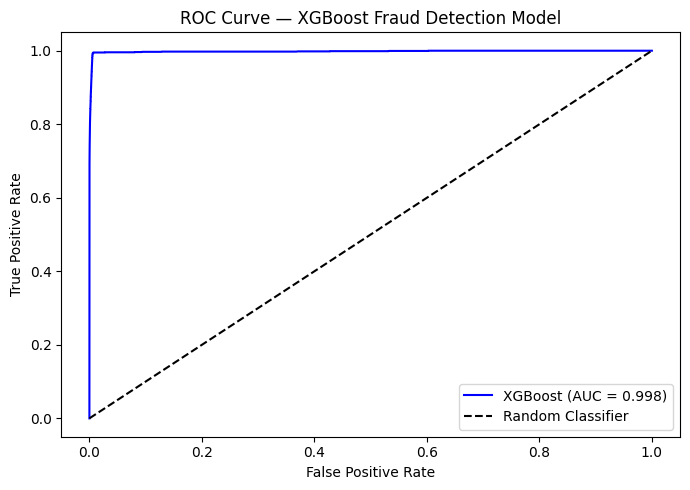

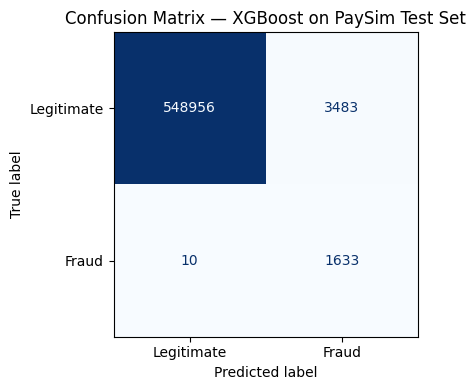

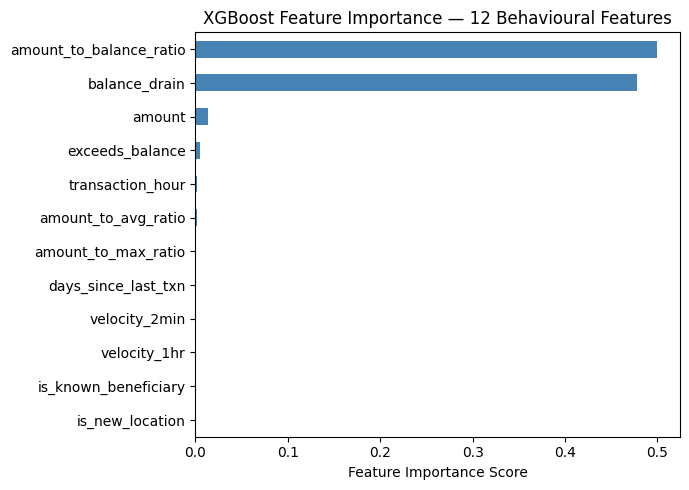

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
import pandas as pd

# Redefine FEATURE_NAMES
FEATURE_NAMES = [
    'amount',
    'amount_to_avg_ratio',
    'amount_to_max_ratio',
    'amount_to_balance_ratio',
    'velocity_2min',
    'velocity_1hr',
    'is_known_beneficiary',
    'is_new_location',
    'transaction_hour',
    'days_since_last_txn',
    'balance_drain',
    'exceeds_balance',
]

# Recompute predictions
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]
auc     = roc_auc_score(y_test, y_proba)

# 1. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color='blue', label=f'XGBoost (AUC = {auc:.3f})')
plt.plot([0,1],[0,1],'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — XGBoost Fraud Detection Model')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

# 2. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legitimate','Fraud'])
fig, ax = plt.subplots(figsize=(5,4))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — XGBoost on PaySim Test Set')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# 3. Feature Importance
feat_imp = pd.Series(model.feature_importances_, index=FEATURE_NAMES).sort_values()
plt.figure(figsize=(7,5))
feat_imp.plot(kind='barh', color='steelblue')
plt.xlabel('Feature Importance Score')
plt.title('XGBoost Feature Importance — 12 Behavioural Features')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()